# F7 — Week 11 Performance Review

**Objective**: Review the optimisation performance of F7 across all 11 submission rounds and propose strategy for next submission.

**Function**: F7 (6D input, 1D output, maximisation)

**Week 10 Strategy**: Neural Network (6→5→5→1, dropout=0.05) + 50%mean/50%EI blend + interior penalty (STEEPNESS=0.02) + 50k candidates.

This notebook loads the Week 11 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 7
N_DIMS = 6
N_INITIAL = 30
WEEK = 11
USE_LOG_SCALE = False
DATA_DIR = '../../data/f7/'

## Step 1 — Load Data

In [22]:
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F7 — Week 11 Data Summary
  Input dimensions:  6
  Total samples:     41
  Initial samples:   30
  Submissions:       11
  Input shape:       (41, 6)
  Output shape:      (41,)
  Best output:       2.30499
  Worst output:      0.00270147

Sample | x1 | x2 | x3 | x4 | x5 | x6 | y
-------------------------------------------------------------------------------------------------
   1(init) | 0.272624 | 0.324495 | 0.897109 | 0.832951 | 0.154063 | 0.795864 | 0.604433
   2(init) | 0.543003 | 0.924694 | 0.341567 | 0.646486 | 0.718440 | 0.343133 | 0.562753
   3(init) | 0.090832 | 0.661529 | 0.065931 | 0.258577 | 0.963453 | 0.640265 | 0.00750324
   4(init) | 0.118867 | 0.615055 | 0.905816 | 0.855300 | 0.413631 | 0.585236 | 0.0614243
   5(init) | 0.630218 | 0.838097 | 0.680013 | 0.731895 | 0.526737 | 0.348429 | 0.273047
   6(init) | 0.764919 | 0.255883 | 0.609084 | 0.218079 | 0.322943 | 0.095794 | 0.0837466
   7(init) | 0.057896 | 0.491672 | 0.247422 | 0.218118 | 0.420428 | 0.730970 | 1.36497
   

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

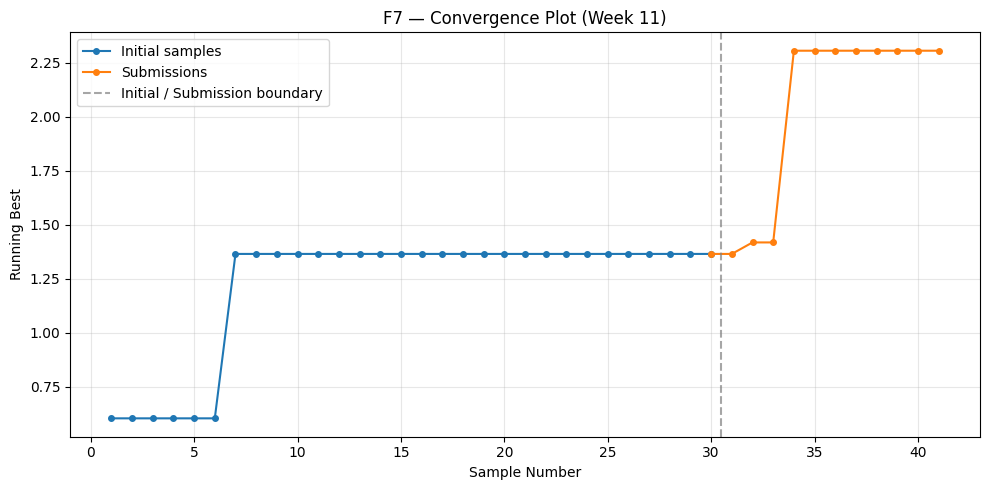

In [23]:
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))
x_all = np.arange(1, n_total + 1)

ax.plot(x_all[:N_INITIAL], running_best[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=4)
ax.plot(x_all[N_INITIAL-1:], running_best[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=4)
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_ylabel('Running Best')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue**, submission samples in **orange** (numbered by week). With 6 dimensions there are 15 pairs.

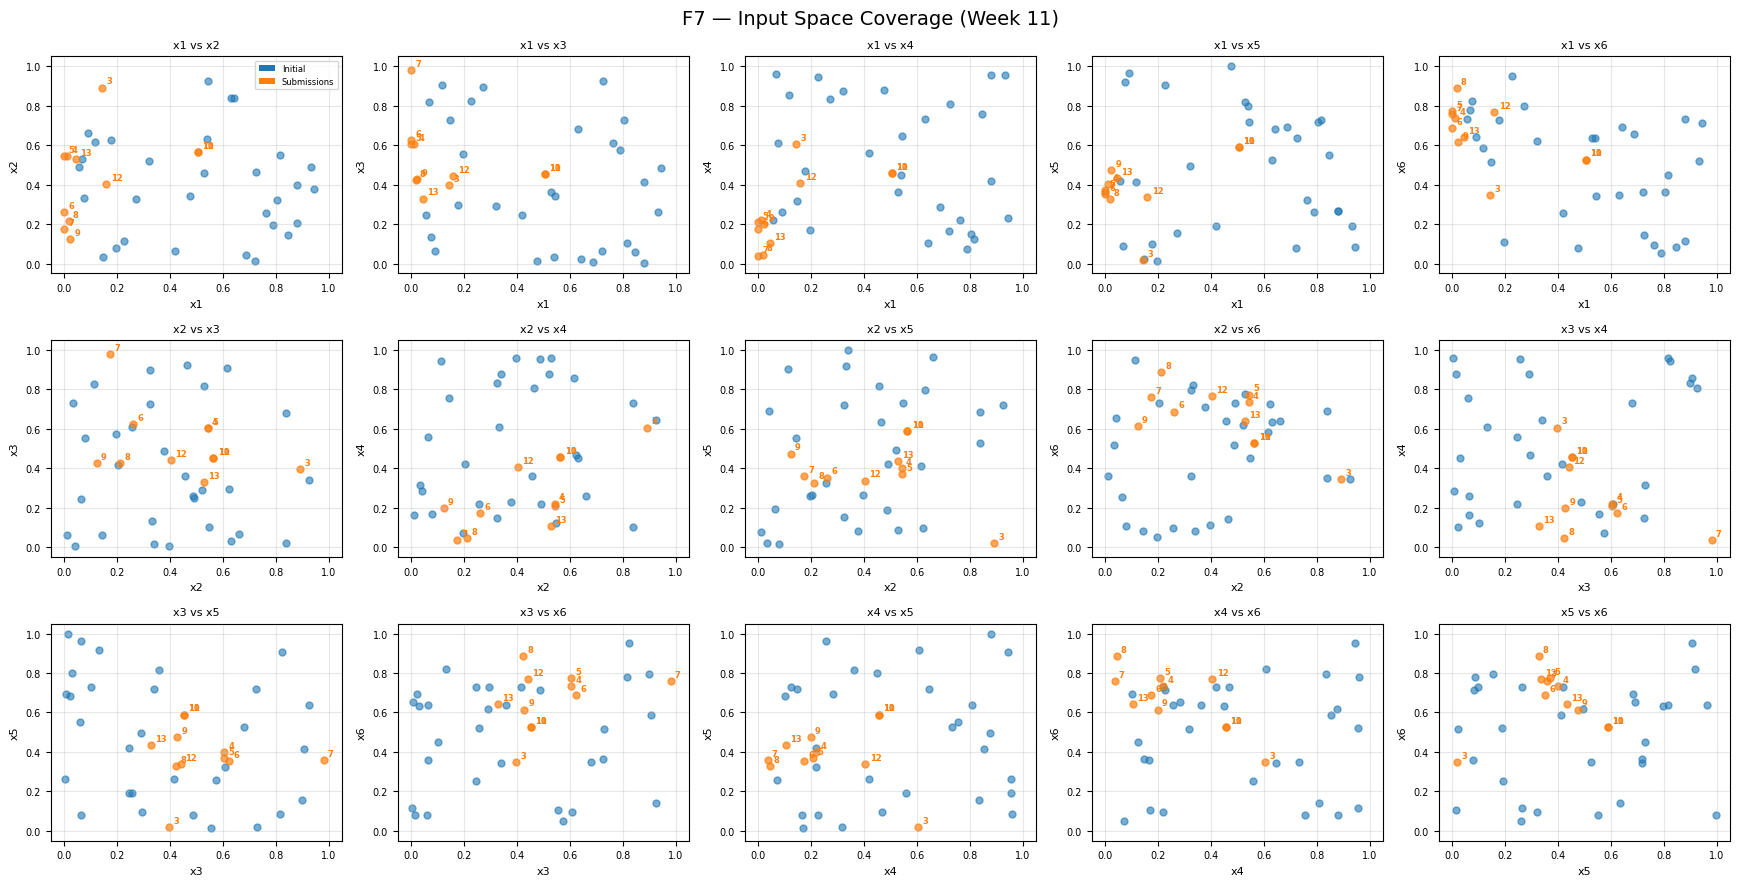

In [24]:
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

n_cols = 5
n_rows = math.ceil(n_pairs / n_cols)
fig_width = n_cols * 3.5
fig_height = n_rows * 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                         squeeze=False)

for idx, (di, dj) in enumerate(pairs):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
               c='tab:blue', marker='o', s=25, alpha=0.6, label='Initial')

    for k in range(N_INITIAL, n_total):
        week_num = k - N_INITIAL + 3
        ax.scatter(inputs[k, di], inputs[k, dj],
                   c='tab:orange', marker='o', s=25, alpha=0.7)
        ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                    textcoords='offset points', xytext=(3, 3),
                    fontsize=6, color='tab:orange', fontweight='bold')

    ax.set_xlabel(f'x{di+1}', fontsize=8)
    ax.set_ylabel(f'x{dj+1}', fontsize=8)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'x{di+1} vs x{dj+1}', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                   Patch(facecolor='tab:orange', label='Submissions')]
axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=6)

for idx in range(n_pairs, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
fig.tight_layout()
plt.show()

## Step 4 — Performance Evaluation

### Week 10 Strategy

- **Surrogate**: Neural Network (6→5→5→1, dropout=0.05) — non-GP approach
- **Acquisition**: 50% predicted-mean + 50% Expected Improvement blend + interior penalty (STEEPNESS=0.02)
- **Key features**: 50k candidate points, 150 epochs, LR=0.005, batch_size=16
- **Rationale**: F7 is 6D — GPs struggle with high dimensions and limited data; NN was chosen as an alternative

### Performance Summary

In [25]:
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     1.36497
Best value (final):       2.30499
Improvements:             2/11
Max consecutive no-improve: 7
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |       0.285444 |        1.36497 | ✗
   4 |        1.41816 |        1.41816 | ✓
   5 |        1.40491 |        1.41816 | ✗
   6 |        2.30499 |        2.30499 | ✓
   7 |       0.747724 |        2.30499 | ✗
   8 |        1.17215 |        2.30499 | ✗
   9 |        1.91349 |        2.30499 | ✗
  10 |       0.300001 |        2.30499 | ✗
  11 |       0.300001 |        2.30499 | ✗
  12 |        2.04327 |        2.30499 | ✗
  13 |          1.051 |        2.30499 | ✗


## Step 5 — Strategy Proposals for Next Submission

Review the performance metrics and convergence plot above. Key considerations for F7:

1. **F7 uses a Neural Network surrogate** (unique among all functions). The 6D space with ~39 samples is challenging for standard GPs.

2. **If week 11 improved**: The NN approach + blended acquisition is working. To maintain:
   - Keep the same NN architecture (6→5→5→1)
   - Consider increasing exploitation: shift blend to 60%mean / 40%EI
   - Reduce STEEPNESS from 0.02 to 0.01 to allow more boundary exploration if needed
   - Increase candidate points from 50k to 75k for better 6D coverage

3. **If week 11 did NOT improve**: The NN may be underfitting or the blend is too exploitative:
   - **Widen the NN**: Try 6→8→8→1 to increase model capacity — 39 samples can support a slightly larger network
   - **Increase dropout to 0.1** for better generalisation / implicit exploration
   - **Shift to pure EI** (100% EI, 0% mean) for one round to diversify
   - **Try ensemble of 5 NNs** using different random seeds — use mean prediction for stability, variance for exploration
   - **Alternative: Switch to SFGP Matérn-2.5 ARD** with high noise + Standardize — the dataset may now be large enough for GP

4. **General**: F7 had 2/10 improvements with 6 consecutive non-improving rounds — a severe stalling problem. The 6D search space is the second largest. The NN approach was chosen because GP struggled, but the NN may also be struggling with so few data points. An ensemble approach or reverting to GP with ARD (now with 39+ samples) may be worth testing.

## ARD Feature Relevance Analysis (Diagnostic GP)

**Note:** F7 uses a Neural Network surrogate for optimisation, not a GP. To analyse feature relevance via ARD lengthscales, we fit a **diagnostic** SingleTaskGP with a Matérn-2.5 ARD kernel on the same data. This GP is used solely for interpretability — it does not replace the NN surrogate.

**Smaller lengthscale → the model is more sensitive to that dimension → higher relevance.**

In [ ]:
import torch
import gpytorch
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.priors import GammaPrior
from gpytorch.constraints import GreaterThan

# Prepare training data (diagnostic GP with Standardize)
X_train = torch.tensor(inputs, dtype=torch.float64)
Y_train = torch.tensor(outputs, dtype=torch.float64).unsqueeze(-1)

# Fit diagnostic SingleTaskGP with Matérn-2.5 ARD kernel
covar_module = ScaleKernel(
    MaternKernel(nu=2.5, ard_num_dims=N_DIMS, lengthscale_prior=GammaPrior(3.0, 6.0)),
    outputscale_prior=GammaPrior(2.0, 0.15),
)
model = SingleTaskGP(X_train, Y_train, covar_module=covar_module, outcome_transform=Standardize(m=1))
model.likelihood.noise_covar.register_constraint("raw_noise", GreaterThan(1e-4))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

# Extract ARD lengthscales
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
dim_names = ["learning_rate", "reg_strength", "n_layers", "dropout", "batch_size", "optimizer"]

print(f"F{FUNC_NUM}: ARD Lengthscales (Diagnostic Matérn-2.5 kernel)")
print(f"{'Dimension':<15} {'Lengthscale':>12}")
print("-" * 28)
for name, ls in zip(dim_names, lengthscales):
    print(f"{name:<15} {ls:>12.6f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute normalised relevance: relevance = 1/lengthscale, then normalise to sum to 1
inv_lengthscales = 1.0 / lengthscales
relevance = inv_lengthscales / inv_lengthscales.sum()

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(8, max(3, len(dim_names) * 0.6)))
y_pos = np.arange(len(dim_names))
bars = ax.barh(y_pos, relevance, color="steelblue", edgecolor="black", height=0.5)

# Annotate bars with percentage
for bar, rel in zip(bars, relevance):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{rel:.1%}", va="center", fontsize=11)

ax.set_yticks(y_pos)
ax.set_yticklabels(dim_names, fontsize=11)
ax.set_xlabel("Normalised Relevance", fontsize=12)
ax.set_title(f"F{FUNC_NUM}: ARD Feature Relevance (Diagnostic Matérn-2.5 kernel)", fontsize=13, fontweight="bold")
ax.set_xlim(0, min(1.0, relevance.max() * 1.3))
ax.invert_yaxis()
plt.tight_layout()
plt.show()